# LangGraph QuickStart

LangGraph는 상태 기반 멀티 액터 애플리케이션을 구축하기 위한 프레임워크입니다.

## 구현 기능

- 상태 관리 기반 챗봇
- 외부 도구 연동 (Tavily Search)
- 메모리 및 체크포인트
- Human-in-the-Loop
- 상태 커스터마이징

## 환경 설정

LangGraph를 사용하기 위해 필요한 환경 변수와 로깅을 설정합니다. `.env` 파일에 API 키를 저장하고, LangSmith를 통해 실행 과정을 추적할 수 있습니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 추적을 위한 프로젝트 이름 설정
logging.langsmith("LangChain-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-V1-Tutorial


---

## 기본 챗봇 구축

메시지 기반 챗봇을 StateGraph로 구성합니다. StateGraph는 LangGraph의 핵심 구성 요소로, 노드와 엣지를 연결하여 상태 기반 워크플로우를 정의합니다.

> 📖 **참고 문서**: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api.md)

### 구성 요소

| 구성 요소 | 설명 |
|----------|------|
| StateGraph | 전체 워크플로우 흐름을 정의하는 그래프 |
| State | 그래프 실행 중 데이터를 저장하는 상태 객체 |
| Node | 실제 작업을 수행하는 함수 (예: LLM 호출) |
| Edge | 노드 간 실행 경로를 연결 |
| Compile/Invoke | 그래프를 실행 가능한 형태로 변환 및 호출 |

아래 코드는 State 타입을 정의하고 StateGraph 인스턴스를 생성합니다.

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# State 정의: 챗봇의 상태를 나타내는 타입
class State(TypedDict):
    """챗봇의 상태를 정의하는 타입

    messages: 대화 메시지 리스트
    - add_messages 함수를 통해 새 메시지가 추가됨 (덮어쓰기가 아닌 추가)
    """

    messages: Annotated[list, add_messages]


# StateGraph 생성
graph_builder = StateGraph(State)

print("StateGraph 생성 완료!")
print("State는 messages 키를 가지며, add_messages 리듀서를 사용합니다.")

StateGraph 생성 완료!
State는 messages 키를 가지며, add_messages 리듀서를 사용합니다.


### LLM 설정

LangGraph의 노드에서 사용할 언어 모델을 설정합니다. `init_chat_model` 함수를 사용하면 다양한 제공자(OpenAI, Anthropic 등)의 모델을 통일된 인터페이스로 사용할 수 있습니다.

아래 코드는 OpenAI의 GPT-5.4 모델을 초기화합니다.

In [3]:
from langchain.chat_models import init_chat_model

# 모델 식별자 문자열을 사용한 간단한 방법
llm = init_chat_model("openai:gpt-5.4")

### 챗봇 노드 추가

노드는 그래프에서 실제 작업을 수행하는 함수입니다. 챗봇 노드는 현재 상태의 메시지를 받아 LLM에 전달하고, 응답을 새 메시지로 추가하여 반환합니다.

`add_node` 메서드의 첫 번째 인자는 노드의 고유 이름이고, 두 번째 인자는 호출될 함수입니다.

아래 코드는 챗봇 노드 함수를 정의하고 그래프에 추가합니다.

In [4]:
def chatbot(state: State):
    """챗봇 노드 함수

    현재 상태의 메시지를 받아 LLM에 전달하고,
    응답을 새 메시지로 추가하여 반환합니다.
    """
    # LLM을 호출하여 응답 생성
    response = llm.invoke(state["messages"])

    # 응답을 메시지 리스트에 추가하여 반환
    return {"messages": [response]}


# 그래프에 노드 추가
# 첫 번째 인자: 노드의 고유 이름
# 두 번째 인자: 노드가 사용될 때 호출될 함수
graph_builder.add_node("chatbot", chatbot)

### 엣지 설정

엣지는 노드 간의 실행 흐름을 정의합니다. `START`는 그래프 실행의 시작점이고, `END`는 종료점입니다. 모든 그래프는 반드시 시작점과 종료점을 가져야 합니다.

아래 코드는 실행 경로(START → chatbot → END)를 설정합니다.

In [5]:
# 진입점: 그래프 실행이 시작되는 지점
graph_builder.add_edge(START, "chatbot")

# 종료점: 그래프 실행이 끝나는 지점
graph_builder.add_edge("chatbot", END)

print("진입점과 종료점 설정 완료!")
print("실행 흐름: START → chatbot → END")

진입점과 종료점 설정 완료!
실행 흐름: START → chatbot → END


### 그래프 컴파일

StateGraph를 정의한 후에는 반드시 `compile()` 메서드를 호출하여 실행 가능한 형태로 변환해야 합니다. 컴파일 과정에서 노드 간 연결이 검증되고, 실행 순서가 결정됩니다.

아래 코드는 정의한 그래프를 컴파일하고 실행 가능한 객체를 반환합니다.

In [6]:
# 그래프 컴파일
graph = graph_builder.compile()

print("그래프 컴파일 완료!")

그래프 컴파일 완료!


### 그래프 시각화

컴파일된 그래프의 구조를 시각적으로 확인할 수 있습니다. `langchain_teddynote` 패키지의 `visualize_graph` 함수를 사용하면 노드와 엣지의 연결 상태를 한눈에 파악할 수 있습니다.

아래 코드는 컴파일된 그래프를 시각화합니다.

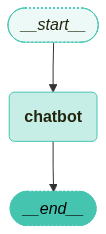

In [7]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph)

### 그래프 실행

`stream_graph` 함수를 사용하면 그래프 실행 결과를 스트리밍 방식으로 출력할 수 있습니다. `RunnableConfig`를 통해 재귀 깊이 제한(`recursion_limit`)과 스레드 식별자(`thread_id`)를 설정합니다.

아래 코드는 Config를 설정하고 사용자 입력을 준비합니다.

In [8]:
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
from langchain.messages import HumanMessage

# Config 설정(recursion_limit: 재귀 깊이 제한, thread_id: 스레드 아이디)
config = RunnableConfig(recursion_limit=20, thread_id="abc123")

In [9]:
inputs = {
    "messages": [HumanMessage(content="안녕하세요! LangGraph에 대해 알려주세요.")]
}

# 그래프 스트리밍
stream_graph(graph, inputs=inputs, config=config)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! 물론이죠.  
**LangGraph**는 **LLM(대규모 언어 모델) 기반 애플리케이션을 상태 기반 그래프(stateful graph) 형태로 설계하고 실행할 수 있게 해주는 프레임워크**입니다. 쉽게 말하면:

- 단순한 한 번의 LLM 호출이 아니라
- **여러 단계의 작업 흐름**
- **조건 분기**
- **반복 루프**
- **에이전트 실행**
- **도구 호출**
- **상태 관리**

같은 복잡한 동작을 더 체계적으로 만들 수 있게 해줍니다.

---

## 1. 왜 LangGraph가 필요한가요?

기본적인 LLM 앱은 보통 이런 식입니다:

1. 사용자 입력 받기
2. LLM에 전달
3. 결과 반환

하지만 실제로는 더 복잡한 경우가 많습니다.

예:
- 질문을 먼저 분류하고
- 필요하면 검색 도구를 사용하고
- 결과를 검증하고
- 부족하면 다시 검색하고
- 최종 답변을 생성

이런 흐름은 단순 체인(chain)으로 만들기 어렵습니다.  
특히 **반복**과 **조건 분기**가 들어가면 관리가 복잡해집니다.

LangGraph는 이런 문제를 해결하기 위해 등장했습니다.

---

## 2. LangGraph의 핵심 개념

LangGraph의 핵심은 **그래프**입니다.

그래프는 보통 다음으로 구성됩니다:

- **Node(노드)**: 하나의 작업 단위  
  예: LLM 호출, 검색, 요약, 검증
- **Edge(엣지)**: 노드 간 연결  
  예: “이 작업이 끝나면 다음 작업으로 이동”
- **State(상태)**: 그래프 전체에서 공유되는 데이터  
  예: 사용자 질문, 중간 결과, 검색 문서, 최종 답변

즉, LangGraph는  
**“상태를 가지고 여러 작업 노드를 흐르게 하는 시스템”**이라고 볼 수 있습니다.

---

## 3. LangChain과는 무엇이 다른가요?

LangGrap

---

## 도구(Tools) 추가

외부 검색 도구를 통합하여 실시간 정보를 조회할 수 있는 챗봇을 만듭니다. LangGraph는 LLM이 외부 도구를 호출하고 그 결과를 활용하는 워크플로우를 쉽게 구성할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Tool Integration](https://docs.langchain.com/oss/python/langgraph/tool-integration.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Tool Binding | LLM에 사용 가능한 도구를 연결하는 과정 |
| Tool Node | 실제 외부 API를 호출하는 노드 |
| Conditional Edges | LLM 응답에 따라 도구 사용 여부를 자동 분기 |

아래 코드는 간단한 덧셈 도구를 정의합니다.

In [10]:
# 공유
from langchain.tools import tool


@tool
def add(a: int, b: int):
    "두 숫자를 더합니다."
    return a + b

In [ ]:
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition

# Tavily 검색 도구 설정
tool = TavilySearch(max_results=2)
tools = [tool, add]

# 도구 테스트
result = tool.invoke("LangGraph란 무엇인가요?")
print(f"검색 결과 수: {len(result['results'])}개")
print(f"첫 번째 결과 제목: {result['results'][0]['title']}")
print(f"두 번째 결과 제목: {result['results'][1]['title']}")                        ## 꿈 많은 사람의 이야기 -> 이거 뭐임 ?

검색 결과 수: 2개
첫 번째 결과 제목: LangGraph란 무엇인가요? | IBM
두 번째 결과 제목: 꿈 많은 사람의 이야기


### 도구 사용 그래프 구성

기본 챗봇 흐름에 도구 호출 경로를 추가합니다. LLM이 도구 호출을 요청하면 "tools" 노드로 이동하고, 도구 실행 후 다시 챗봇으로 돌아오는 순환 구조(chatbot ⇄ tools)를 구성합니다.

아래 코드는 LLM에 도구를 바인딩합니다.

In [15]:
llm_with_tools = llm.bind_tools(tools)

In [16]:
ret1 = llm_with_tools.invoke("LangGraph 가 뭐야?")
ret2 = llm_with_tools.invoke("LangGraph 가 뭐야? 검색해서 알려줘")

In [17]:
print(ret1.content)

LangGraph는 **LLM 애플리케이션을 그래프(graph) 구조로 설계·실행하는 프레임워크**예요.  
쉽게 말하면, 단순한 “프롬프트 1번 호출”이 아니라:

- 어떤 단계들을 거칠지
- 중간 상태를 어떻게 저장할지
- 조건에 따라 어디로 분기할지
- 실패하면 어떻게 재시도할지
- 여러 에이전트/도구를 어떻게 연결할지

이런 걸 **노드(node)와 엣지(edge)**로 표현해서 만드는 도구입니다.

### 왜 쓰냐?
일반적인 체인은 보통 직선형이에요:

`입력 → LLM 호출 → 출력`

그런데 실제 에이전트 시스템은 더 복잡하죠:

`입력 → 계획 세우기 → 도구 호출 → 결과 검증 → 부족하면 다시 검색 → 최종 답변`

이런 **반복(loop), 분기(branch), 상태 관리**가 필요할 때 LangGraph가 잘 맞습니다.

### 핵심 개념
- **State**: 현재까지의 작업 상태
  - 예: 사용자 질문, 검색 결과, 중간 추론, 최종 답변
- **Node**: 하나의 작업 단위
  - 예: “질문 분석”, “검색”, “답변 생성”
- **Edge**: 다음에 어떤 노드로 갈지 연결
- **Conditional Edge**: 조건에 따라 다른 노드로 이동
  - 예: 검색 결과가 부족하면 다시 검색
- **Loop**: 만족할 때까지 반복 가능

### 어디에 쓰나?
- AI 에이전트
- RAG 파이프라인
- 툴 사용하는 챗봇
- 멀티 에이전트 시스템
- 사람 승인(human-in-the-loop) 워크플로우

### LangChain이랑 차이
- **LangChain**: LLM 앱을 구성하는 다양한 컴포넌트/체인 중심
- **LangGraph**: **상태 기반의 복잡한 실행 흐름**을 더 잘 다룸

즉,  
- 간단한 순차 처리 → LangChain만으로 충분할 수 있고
- 복잡한 에이전트 흐름, 루프, 분기 → LangGraph가 더 적합합니다

### 아주 짧은 비유
- **LangChain** = 함수들을 순서대로 잇는 파이

In [18]:
from langchain_teddynote.messages import display_message_tree

display_message_tree(ret1)

    content: "LangGraph는 **LLM 애플리케이션을 그래프(graph) 구조로 설계·실행하는 프레임워크**예요.  
쉽게 말하면, 단순한 “프롬프트 1번 호출”이 아니라:

- 어떤 단계들을 거칠지
- 중간 상태를 어떻게 저장할지
- 조건에 따라 어디로 분기할지
- 실패하면 어떻게 재시도할지
- 여러 에이전트/도구를 어떻게 연결할지

이런 걸 **노드(node)와 엣지(edge)**로 표현해서 만드는 도구입니다.

### 왜 쓰냐?
일반적인 체인은 보통 직선형이에요:

`입력 → LLM 호출 → 출력`

그런데 실제 에이전트 시스템은 더 복잡하죠:

`입력 → 계획 세우기 → 도구 호출 → 결과 검증 → 부족하면 다시 검색 → 최종 답변`

이런 **반복(loop), 분기(branch), 상태 관리**가 필요할 때 LangGraph가 잘 맞습니다.

### 핵심 개념
- **State**: 현재까지의 작업 상태
  - 예: 사용자 질문, 검색 결과, 중간 추론, 최종 답변
- **Node**: 하나의 작업 단위
  - 예: “질문 분석”, “검색”, “답변 생성”
- **Edge**: 다음에 어떤 노드로 갈지 연결
- **Conditional Edge**: 조건에 따라 다른 노드로 이동
  - 예: 검색 결과가 부족하면 다시 검색
- **Loop**: 만족할 때까지 반복 가능

### 어디에 쓰나?
- AI 에이전트
- RAG 파이프라인
- 툴 사용하는 챗봇
- 멀티 에이전트 시스템
- 사람 승인(human-in-the-loop) 워크플로우

### LangChain이랑 차이
- **LangChain**: LLM 앱을 구성하는 다양한 컴포넌트/체인 중심
- **LangGraph**: **상태 기반의 복잡한 실행 흐름**을 더 잘 다룸

즉,  
- 간단한 순차 처리 → LangChain만으로 충분할 수 있고
- 복잡한 에이전트 흐름, 루프, 분기 → LangGraph가 더 적합합니다

### 아주 짧은 비유
- **LangChain** = 함

In [ ]:
display_message_tree(ret2)

In [20]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# State 정의 (동일)
class State(TypedDict):
    messages: Annotated[list, add_messages]


# 새로운 그래프 빌더 생성
builder = StateGraph(State)

# LLM에 도구 바인딩 - LLM이 도구를 사용할 수 있도록 설정
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    """도구를 사용할 수 있는 챗봇 노드"""
    # 도구가 바인딩된 LLM 호출
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# 노드 추가
builder.add_node("chatbot", chatbot)

# ToolNode 추가 - 도구를 실행하는 노드
tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)

### 조건부 라우팅

`tools_condition`이 마지막 AI 메시지의 `tool_calls` 존재 여부를 확인해 경로를 분기합니다.

### tools_condition 동작

`tool_calls` 존재 시 "tools"로, 없으면 "\_\_end\_\_"로 분기합니다.

```python
def tools_condition(state) -> Literal["tools", "__end__"]:
    ai_message = state[-1] if isinstance(state, list) else state["messages"][-1]
    return "tools" if getattr(ai_message, "tool_calls", []) else "__end__"
```

In [21]:
# 조건부 엣지 추가
# tools_condition은 메시지에 tool_calls가 있으면 "tools"로,
# 없으면 END로 라우팅합니다
builder.add_conditional_edges(
    "chatbot",
    tools_condition,  # 사전 정의된 조건 함수 사용
)
# Literal["tools", "__end__"]

# 도구 실행 후 다시 챗봇으로 돌아가기
builder.add_edge("tools", "chatbot")

# 시작점 설정
builder.add_edge(START, "chatbot")

# 그래프 컴파일
graph_with_tools = builder.compile()

### 그래프 시각화

도구가 연결된 그래프의 구조를 시각화합니다. chatbot 노드에서 조건에 따라 tools 노드로 분기하는 구조를 확인할 수 있습니다.

아래 코드는 도구가 연결된 그래프를 시각화합니다.

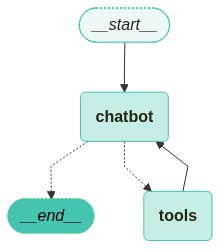

In [22]:
# 그래프 시각화
visualize_graph(graph_with_tools)

### 도구 사용 테스트

Tavily 검색 도구를 활용하여 최신 정보를 검색하는 테스트를 수행합니다. LLM이 질문에 답하기 위해 필요하다고 판단하면 자동으로 검색 도구를 호출합니다.

아래 코드는 2025년 LangGraph 사용 사례에 대한 검색을 수행합니다.

In [ ]:
from langchain_teddynote.messages import stream_graph

stream_graph(
    graph_with_tools,
    inputs={
        "messages": [HumanMessage(content="2025년 LangGraph 사용 사례 알려주세요.")]
    },
    config=config,
)

---

## 메모리 추가

세션 간 사용자 정보를 유지하는 영구 상태 관리를 추가합니다. 메모리 기능을 통해 챗봇이 이전 대화 내용을 기억하고, 사용자별로 개인화된 응답을 제공할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Persistence](https://docs.langchain.com/oss/python/langgraph/persistence.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Checkpointer | 그래프 실행 중 상태를 저장하고 복원하는 컴포넌트 |
| Thread ID | 동일 세션을 식별하는 고유 식별자 |
| User ID | 사용자별 장기 기억을 관리하는 식별자 |
| Persistent State | 누적된 대화 이력 기반의 컨텍스트 |

아래 코드는 메모리 추출을 위한 Pydantic 모델과 추출기를 정의합니다.

In [23]:
from typing import List, Optional
from datetime import datetime
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import PydanticOutputParser
import os


# Pydantic 모델 정의
class MemoryItem(BaseModel):
    """개별 메모리 아이템"""

    key: str = Field(description="메모리 키 (예: user_name, preference, fact)")
    value: str = Field(description="메모리 값")
    category: str = Field(
        description="카테고리 (personal_info, preference, interest, relationship, fact, etc.)"
    )
    importance: int = Field(description="중요도 (1-5, 5가 가장 중요)", ge=1, le=5)
    confidence: float = Field(description="추출 신뢰도 (0.0-1.0)", ge=0.0, le=1.0)


class ExtractedMemories(BaseModel):
    """추출된 메모리 컬렉션"""

    memories: List[MemoryItem] = Field(description="추출된 메모리 아이템 리스트")
    summary: str = Field(description="대화 내용 요약")
    timestamp: str = Field(
        default_factory=lambda: datetime.now().isoformat(), description="추출 시간"
    )


# 기본 시스템 프롬프트
DEFAULT_SYSTEM_PROMPT = """You are an expert memory extraction assistant. Your task is to extract important information from user conversations and convert them into structured key-value pairs for long-term memory storage.

Extract ALL relevant information from the conversation, including:
- Personal information (name, age, location, occupation, etc.)
- Preferences and interests
- Relationships and social connections
- Important facts or events mentioned
- Opinions and beliefs
- Goals and aspirations
- Any other notable information

For each piece of information:
1. Create a concise, searchable key
2. Store the complete value
3. Categorize appropriately
4. Assess importance (1-5 scale)
5. Evaluate extraction confidence (0.0-1.0)"""


def create_memory_extractor(
    model_name: Optional[str] = "openai:gpt-5.4",
    system_prompt: Optional[str] = None,
) -> any:                                                    ## Any: 타입 검사에서 어떤 값이든 허용한다는 타입 -> 으로 변경 필요 ?
    """메모리 추출기를 생성합니다.

    Args:
        model: 사용할 언어 모델. None일 경우 기본 ChatOpenAI 모델 사용          ## 이것도 model_name으로 수정 필요 ?
        system_prompt: 시스템 프롬프트. None일 경우 기본 프롬프트 사용

    Returns:
        메모리 추출 체인
    """
    # Output Parser 생성
    memory_parser = PydanticOutputParser(pydantic_object=ExtractedMemories)

    # 시스템 프롬프트 설정
    if system_prompt is None:
        system_prompt = DEFAULT_SYSTEM_PROMPT

    # 전체 프롬프트 템플릿 구성
    template = f"""{system_prompt}

User Input: {{input}}

{{format_instructions}}

Remember to:
- Extract multiple memory items if the conversation contains various pieces of information
- Use clear, consistent key naming conventions
- Preserve context in values when necessary
- Be comprehensive but avoid redundancy
"""

    # 프롬프트 생성
    prompt = ChatPromptTemplate.from_template(
        template,
        partial_variables={
            "format_instructions": memory_parser.get_format_instructions()
        },
    )

    # 모델 설정
    model = init_chat_model(model_name)

    # 메모리 추출 체인 생성
    memory_extractor = prompt | model | memory_parser

    return memory_extractor

In [24]:
from typing import Any
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.store.base import BaseStore
from langchain_openai import ChatOpenAI

from langchain_teddynote.memory import create_memory_extractor
import uuid

model = init_chat_model("openai:gpt-5.4")
memory_extractor = create_memory_extractor(model="openai:gpt-5.4")


def call_model(
    state: MessagesState,
    config: RunnableConfig,
    *,
    store: BaseStore,
) -> dict[str, Any]:
    """LLM 모델을 호출하고 사용자 메모리를 관리합니다.

    Args:
        state (MessagesState): 메시지를 포함하는 현재 상태
        config (RunnableConfig): 실행 가능 구성
        store (BaseStore): 메모리 저장소
    """
    # 마지막 메시지에서 user_id 추출
    user_id = config["configurable"]["user_id"]
    namespace = ("memories", user_id)

    print(namespace)

    # 유저의 메모리 검색
    memories = store.search(namespace, query=str(state["messages"][-1].content))
    info = "\n".join([f"{memory.key}: {memory.value}" for memory in memories])
    system_msg = f"You are a helpful assistant talking to the user. User info: {info}"

    # 사용자가 기억 요청 시 메모리 저장
    last_message = state["messages"][-1]
    if "remember" in last_message.content.lower():
        result = memory_extractor.invoke({"input": str(state["messages"][-1].content)})
        for memory in result.memories:
            print(memory)
            print("-" * 100)
            store.put(namespace, str(uuid.uuid4()), {memory.key: memory.value})

    # LLM 호출
    response = model.invoke(
        [{"role": "system", "content": system_msg}] + state["messages"]
    )
    return {"messages": response}

In [25]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

# 그래프 빌드
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

# 메모리 체크포인터 생성
# 실제 프로덕션에서는 PostgresSaver 사용 권장
memory_saver = InMemorySaver()
memory_store = InMemoryStore()

# 그래프 컴파일
graph_with_memory = builder.compile(
    checkpointer=memory_saver,
    store=memory_store,
)

In [26]:
from langchain_teddynote.messages import stream_graph


def run_graph(
    msg,
    thread_id="default",
    user_id="default",
):
    config = {
        "configurable": {
            "thread_id": thread_id + user_id,
            "user_id": user_id,
        }
    }
    print(f"\n[유저] {msg}")
    stream_graph(
        graph_with_memory,
        inputs={"messages": [{"role": "user", "content": msg}]},
        config=config,
    )
    print()

In [27]:
# 메시지, thread_id, user_id 전달
run_graph("안녕? 내 이름은 테디야", "1", "someone")


[유저] 안녕? 내 이름은 테디야
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕, 테디! 만나서 반가워 😊  
무엇을 도와줄까?


In [28]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "1", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
테디! 😊


In [29]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "2", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
아직 이름을 알려주지 않으셨어요.  
원하시면 지금 알려주시면 기억해서 그렇게 불러드릴게요.


### 장기 기억 저장

메시지에 `remember` 키워드 포함 시 장기 저장소에 정보를 기록합니다.

In [30]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 테디야 remember", "2", "someone")


[유저] 내 이름이 테디야 remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "user_name",
      "value": "테디",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 자신의 이름이 테디라고 밝혔다.",
  "timestamp": "2024-06-13T00:00:00Z"
}key='user_name' value='테디' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
알겠어, 테디! 앞으로 그렇게 부를게.


### Thread 간 지속성

User ID 기반 장기 기억은 Thread가 달라도 유지됩니다.

In [31]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고 했더라?", "1004", "someone")


[유저] 내 이름이 뭐라고 했더라?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
테디님이에요.


In [32]:
# 메시지, thread_id, user_id 전달
run_graph(
    "내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember", "4", "someone"
)


[유저] 내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "occupation",
      "value": "AI Engineer",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    },
    {
      "key": "hobby",
      "value": "Netflix 보기",
      "category": "interest",
      "importance": 4,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 자신의 직업이 AI Engineer이며, 취미는 Netflix 보기라고 밝혔다.",
  "timestamp": "2024-06-13T00:00:00Z"
}key='occupation' value='AI Engineer' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
key='hobby' value='Netflix 보기' category='interest' importance=4 confidence=1.0
----------------------------------------------------------------------------------------------------
알겠어, 테디.

기억할게:
- 직업: AI Engineer
- 취미: Netflix 보기

앞으로 

In [33]:
# 다른 스레드에서 실행
run_graph("내 이름, 직업, 취미 알려줘", "100", "someone")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
테디님의 정보는 다음과 같아요:

- 이름: 테디
- 직업: AI Engineer
- 취미: Netflix 보기


In [34]:
# 다른 user_id 로 실행한 경우
run_graph("내 이름, 직업, 취미 알려줘", "100", "other")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'other')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
저는 아직 당신의 이름, 직업, 취미를 알지 못해요.  
말씀해 주시면 기억해서 대화에 반영할게요.

예를 들면 이렇게 알려주시면 돼요:
- 이름: 민수
- 직업: 디자이너
- 취미: 등산, 게임

원하시면 지금 바로 알려주세요.


### State 확인

저장된 상태를 조회하여 메시지 이력과 체크포인트 정보를 확인합니다. `get_state` 메서드를 통해 현재 상태의 스냅샷을 가져올 수 있습니다.

아래 코드는 특정 Config에 대한 현재 상태 정보를 조회합니다.

In [35]:
# 임의의 Config 설정
config = {
    "configurable": {
        "thread_id": "100" + "someone",
        "user_id": "someone",
    }
}

# 현재 상태 가져오기
snapshot = graph_with_memory.get_state(config)

print("현재 상태 정보:")
print(f"- 메시지 수: {len(snapshot.values['messages'])}개")
print(f"- 체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")

# 최근 메시지 몇 개 표시
print("\n[최근 메시지]")
for msg in snapshot.values["messages"]:
    role = msg.type if hasattr(msg, "type") else "unknown"
    content = msg.content if hasattr(msg, "content") else str(msg)
    print(f"  [{role}]: {content}")

현재 상태 정보:
- 메시지 수: 2개
- 체크포인트 ID: 1f1c1358-f6a5-6b46-8001-cee2248e75db

[최근 메시지]
  [human]: 내 이름, 직업, 취미 알려줘
  [ai]: 테디님의 정보는 다음과 같아요:

- 이름: 테디
- 직업: AI Engineer
- 취미: Netflix 보기


---

## Human-in-the-Loop

고위험 작업에 대해 인간 승인을 요청하는 흐름을 도입합니다. 중요한 결정이나 민감한 작업 수행 전에 사람의 확인을 받을 수 있어 AI 시스템의 안전성을 높입니다.

> 📖 **참고 문서**: [LangGraph Interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| interrupt | 그래프 실행을 일시정지하고 외부 입력을 대기 |
| Command | 승인/거부 후 재개 명령을 전달하는 객체 |
| Human Approval | 사람이 검토하고 승인하는 워크플로우 |

아래 코드는 사람의 도움을 요청하는 도구를 정의합니다.

In [36]:
from langchain.tools import tool
from langgraph.types import Command, interrupt


@tool
def human_assistance(query: str) -> str:
    """Request assistance from an expert(human)."""
    # interrupt를 호출하여 실행 일시 중지
    # 사람의 응답을 기다림
    human_response = interrupt({"query": query})

    # 사람의 응답 반환
    return human_response["data"]

### HITL 그래프 구성

`human_assistance` 도구를 사용하는 그래프를 구성합니다. 이 도구가 호출되면 `interrupt`로 실행이 중단되고, 사람의 응답을 기다립니다. 응답이 입력되면 해당 내용을 반환하여 대화를 계속합니다.

아래 코드는 Human-in-the-Loop 기능이 포함된 그래프를 구성합니다.

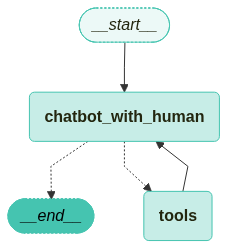

In [37]:
# 도구 리스트 업데이트
tools_with_human = [human_assistance]

# 새로운 그래프 구성
graph_builder_hitl = StateGraph(State)

# LLM에 도구 바인딩
llm_with_human_tools = llm.bind_tools(tools_with_human)


def chatbot_with_human(state: State):
    """Human Interuption 요청할 수 있는 챗봇"""
    message = llm_with_human_tools.invoke(state["messages"])

    # interrupt 중 병렬 도구 호출 방지
    # (재개 시 도구 호출이 반복되는 것을 방지)
    if hasattr(message, "tool_calls"):
        assert (
            len(message.tool_calls) <= 1
        ), "병렬 도구 호출은 interrupt와 함께 사용할 수 없습니다"

    return {"messages": [message]}


# 노드 추가
graph_builder_hitl.add_node("chatbot_with_human", chatbot_with_human)

# ToolNode 추가
tool_node_hitl = ToolNode(tools=tools_with_human)
graph_builder_hitl.add_node("tools", tool_node_hitl)

# 엣지 추가
graph_builder_hitl.add_conditional_edges("chatbot_with_human", tools_condition)
graph_builder_hitl.add_edge("tools", "chatbot_with_human")
graph_builder_hitl.add_edge(START, "chatbot_with_human")

# 메모리와 함께 컴파일
memory_hitl = InMemorySaver()
graph_hitl = graph_builder_hitl.compile(checkpointer=memory_hitl)

# 그래프 시각화
visualize_graph(graph_hitl)

### HITL 테스트

사람에게 조언을 요청하는 질문으로 interrupt와 재개 흐름을 검증합니다. 그래프가 중단되면 `get_state`로 현재 상태를 확인하고, `Command(resume=...)`로 재개할 수 있습니다.

아래 코드는 인간 지원을 요청하는 메시지로 그래프를 실행합니다.

In [38]:
from langchain_teddynote.messages import random_uuid

# 인간 지원을 요청하는 메시지
user_input = "LangGraph 가 뭐야? 사람한테 듣고 싶어."
config_hitl = {"configurable": {"thread_id": random_uuid()}}

print(f"User: {user_input}\n")

stream_graph(
    graph_hitl,
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=config_hitl,
)

User: LangGraph 가 뭐야? 사람한테 듣고 싶어.


🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [39]:
# 상태 확인 - 어느 노드에서 중단되었는지 확인
snapshot = graph_hitl.get_state(config_hitl)
print(f"\n현재 상태:")
print(f"  다음 실행할 노드: {snapshot.next}")
print(f"  체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")


현재 상태:
  다음 실행할 노드: ('tools',)
  체크포인트 ID: 1f1c13e2-afef-62fc-8001-8192c217e1bb


In [40]:
# 인간의 응답으로 실행 재개
human_response = """## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)
"""

# Command 객체로 재개
human_command = Command(resume={"data": human_response})

print(f"\n사람의 응답: {human_response}\n")

# 재개
stream_graph(graph_hitl, inputs=human_command, config=config_hitl)


사람의 응답: ## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)



🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)

🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
사람 설명 느낌으로 말하면:

**LangGraph는 “LLM 앱의 흐름도를 코드로 짜는 도구”**예요.  
특히 **여러 단계가 있고, 중간에 판단해서 분기하고, 반복하고, 상태를 기억해야 하는 AI 워크플로우**를 만들 때 씁니다.

### 쉽게 비유하면
- **LangChain**이 “LLM 기능 블록 모음”에 가깝다면
- **LangGraph**는 그 블록들을 이어서 만드는 **상태 기반 워크플로우 엔진**에 가까워요.

예를 들어 이런 식이죠:

1. 사용자 질문 받기  
2. 검색할지 말지 판단  
3. 검색 수행  
4. 결과가 부족하면 한 번 더 검색  
5. 충분하면 답변 생성  
6. 사람이 중간 검토할 수도 있음

이런 흐름은 그냥 직선형 체인보다 **그래프 구조**가 더 잘 맞아요.  
그래서 이름도 **Graph**입니다.

### 언제 쓰냐?
이럴 때 유용해요:
- **에이전트**를 만들고 싶을 때
- 여러 도구를 쓰는 AI 시스템
- **조건 분기**가 있을 때
- 같은 작업을 **반복(loop)** 해야 할 때
- 실행 중간의 **상태(state)**를 계속 들고 가

---

## 상태 커스터마이징

메시지 외에 업무 데이터를 다루는 커스텀 상태와 도구 기반 상태 업데이트를 도입합니다. `Command` 객체를 사용하면 도구 실행 결과로 상태를 직접 갱신할 수 있습니다.

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Custom State Fields | messages 외에 추가 필드를 정의 |
| State Updates from Tools | 도구 결과로 상태를 직접 갱신 |
| Command(update=...) | 상태 업데이트를 지정하는 명령 객체 |

아래 코드는 `human_feedback` 필드가 추가된 커스텀 상태를 정의합니다.

In [41]:
from langchain.messages import ToolMessage
from langchain.tools import InjectedToolCallId


# 확장된 State 정의
class CustomState(TypedDict):
    """커스텀 필드가 추가된 상태"""

    messages: Annotated[list, add_messages]
    human_feedback: str  # 사람의 피드백

### 상태 업데이트 도구

도구 실행 결과를 `Command(update=...)`로 상태에 반영합니다. 이 패턴을 사용하면 도구가 단순히 문자열을 반환하는 것이 아니라, 상태의 특정 필드를 직접 수정할 수 있습니다.

아래 코드는 인간 검토를 요청하고 피드백에 따라 상태를 업데이트하는 도구를 정의합니다.

In [42]:
@tool
def human_review(
    human_feedback, tool_call_id: Annotated[str, InjectedToolCallId]
) -> str:
    """Request human review for information."""
    # 인간에게 검토 요청
    human_response = interrupt(
        {"question": "이 정보가 맞나요?", "human_feedback": human_feedback}
    )

    feedback = human_response.get("human_feedback", "")

    if feedback.strip() == "":
        # 사용자가 AI 의 답변에 동의하는 경우
        return Command(
            update={
                "messages": [ToolMessage(human_response, tool_call_id=tool_call_id)]
            }
        )
    else:
        # 사용자가 AI 의 답변에 동의하지 않는 경우
        corrected_information = f"# 사용자에 의해 수정된 피드백: {feedback}"
        return Command(
            update={
                "messages": [
                    ToolMessage(corrected_information, tool_call_id=tool_call_id)
                ]
            }
        )

### 커스텀 상태 그래프

`CustomState`를 사용하여 그래프를 구성합니다. 기본 `State` 대신 커스텀 상태를 사용하면 애플리케이션에 필요한 추가 데이터를 관리할 수 있습니다.

아래 코드는 커스텀 상태와 `human_review` 도구를 사용하는 그래프를 구성합니다.

In [43]:
# 도구 리스트
tools_custom = [human_review]

# 새로운 그래프 구성
custom_graph_builder = StateGraph(CustomState)  # CustomState 사용

# LLM에 도구 바인딩
llm_with_custom_tools = llm.bind_tools(tools_custom)


def chatbot_custom(state: CustomState):
    """커스텀 상태를 사용하는 챗봇"""
    message = llm_with_custom_tools.invoke(state["messages"])

    if hasattr(message, "tool_calls"):
        assert len(message.tool_calls) <= 1

    return {"messages": [message]}


# 노드와 엣지 추가
custom_graph_builder.add_node("chatbot", chatbot_custom)
tool_node_custom = ToolNode(tools=tools_custom)
custom_graph_builder.add_node("tools", tool_node_custom)

custom_graph_builder.add_conditional_edges("chatbot", tools_condition)
custom_graph_builder.add_edge("tools", "chatbot")
custom_graph_builder.add_edge(START, "chatbot")

# 컴파일
memory_custom = InMemorySaver()
custom_graph = custom_graph_builder.compile(checkpointer=memory_custom)

### 그래프 시각화

커스텀 상태 그래프의 구조를 시각화합니다. 기본 도구 그래프와 동일한 구조이지만, 내부적으로 `CustomState`를 사용합니다.

아래 코드는 커스텀 상태 그래프를 시각화합니다.

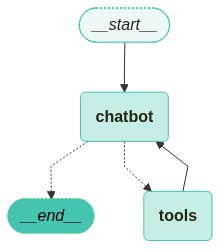

In [44]:
# 그래프 시각화
visualize_graph(custom_graph)

### 커스텀 상태 테스트

`human_review` 도구 호출 시 interrupt로 중단되고, 재개 시 사용자 피드백에 따라 상태가 갱신되는지 확인합니다. 사용자가 빈 피드백을 제공하면 AI의 답변에 동의하는 것으로 처리됩니다.

아래 코드는 인간 검토가 필요한 질문으로 그래프를 실행합니다.

In [45]:
# LangGraph의 출시일을 조사하고 검토 요청
user_input = (
    "2024년 노벨 문학상 수상자가 누구인지 조사해주세요. "
    "답을 찾으면 `human_review` 도구를 사용해서 검토를 요청하세요."
)

custom_config = RunnableConfig(configurable={"thread_id": random_uuid()})

print(f"User: {user_input}\n")

# 실행 (interrupt에서 중단될 것임)
stream_graph(
    custom_graph,
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=custom_config,
)

User: 2024년 노벨 문학상 수상자가 누구인지 조사해주세요. 답을 찾으면 `human_review` 도구를 사용해서 검토를 요청하세요.


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [46]:
from langchain_teddynote.messages import display_message_tree

# 최신 메시지 가져오기
last_message = custom_graph.get_state(custom_config).values["messages"][-1]

# 최신 메시지 tree 구조로 표시
display_message_tree(last_message)

    content: ""
    additional_kwargs: {}
    response_metadata: {"finish_reason": "tool_calls", "model_name": "gpt-5.4-2026-03-05", "service_tier": "default", "model_provider": "openai"}
    type: "ai"
    name: None
    id: "lc_run--01a10f80-48ae-74e1-91b7-80f023417c3a"
    tool_calls:
        index [0]
            name: "human_review"
            args: {"human_feedback": "2024년 노벨 문학상 수상자는 대한민국 작가 한강(Han Kang)입니다. 검토 부탁드립니다."}
            id: "call_eWGLqa9YMuhcVsepe6YphXVJ"
            type: "tool_call"
    invalid_tool_calls:
    usage_metadata:
        input_tokens: 160
        output_tokens: 45
        total_tokens: 205
        input_token_details: {"audio": 0, "cache_read": 0}
        output_token_details: {"audio": 0, "reasoning": 0}


In [47]:
# AI 가 작성한 내용
print(last_message.tool_calls[0]["args"]["human_feedback"])

2024년 노벨 문학상 수상자는 대한민국 작가 한강(Han Kang)입니다. 검토 부탁드립니다.


In [48]:
# 인간의 검토 응답으로 재개
human_command = Command(
    resume={"human_feedback": "2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다."}
)

stream_graph(custom_graph, inputs=human_command, config=custom_config)


🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
# 사용자에 의해 수정된 피드백: 2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다.
🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다.

---

# 🧩 1주차 퀴즈 ③ — LangGraph QuickStart

빈칸(`________`)을 채우고 실행해보세요. 제출 방법은 퀴즈 ①(01-LangGraph-Introduction.ipynb)의 안내와 같습니다.

> ⚠️ 이 퀴즈는 **OpenAI API 키**(`.env`)가 필요합니다.

### Q1. 기본 챗봇 그래프 만들기

노드 추가 → 엣지 연결 → 컴파일까지, StateGraph의 기본 3단계를 완성하세요.

In [49]:
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

load_dotenv(override=True)


class State(TypedDict):
    messages: Annotated[list, add_messages]


llm = init_chat_model("openai:gpt-5.4-mini")


def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


builder = StateGraph(State)

# 1) "chatbot"이라는 이름으로 노드를 추가하세요
builder.add_node("chatbot", chatbot)

# 2) 시작점 → chatbot → 종료점 엣지를 연결하세요
builder.add_edge(START , "chatbot")
builder.add_edge("chatbot", END)

# 3) 그래프를 실행 가능한 형태로 변환하세요
graph = builder.compile()

result = graph.invoke({"messages": [("user", "안녕! 반가워.")]})
print(result["messages"][-1].content)

# ---- 자동 채점: 컴파일된 그래프의 실제 구조를 확인합니다 ----
node_names = set(graph.get_graph().nodes.keys())
edges = {(e.source, e.target) for e in graph.get_graph().edges}

assert "chatbot" in node_names, '"chatbot" 노드가 추가되어야 합니다'
assert ("__start__", "chatbot") in edges, "START → chatbot 엣지가 필요합니다"
assert ("chatbot", "__end__") in edges, "chatbot → END 엣지가 필요합니다"
assert result["messages"][-1].content, "LLM의 답변이 비어 있으면 안 됩니다"
print("통과! 🎉")

안녕! 반가워 😊  
무엇을 도와드릴까요?
통과! 🎉


### Q2. 도구와 조건부 라우팅

chatbot ⇄ tools 순환 구조를 완성하세요. LLM이 도구 호출을 요청하면 tools 노드로, 아니면 END로 분기해야 합니다.

In [50]:
from langchain.tools import tool
from langchain.messages import ToolMessage
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def multiply(a: int, b: int) -> int:
    """두 숫자를 곱합니다."""
    return a * b


tools = [multiply]
llm_with_tools = llm.bind_tools(tools)


def chatbot_with_tools(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("chatbot", chatbot_with_tools)
builder.add_node("tools", ToolNode(tools=tools))
builder.add_edge(START, "chatbot")

# 1) tool_calls 유무에 따라 분기하는 '조건부 엣지'를 추가하세요
builder.add_conditional_edges("chatbot", tools_condition)

# 2) 도구 실행 후 다시 chatbot으로 돌아가는 엣지를 추가하세요
builder.add_edge("tools", "chatbot")

graph_with_tools = builder.compile()

result = graph_with_tools.invoke(
    {"messages": [("user", "127 곱하기 89는? multiply 도구를 사용해서 계산해줘")]}
)
print(result["messages"][-1].content)

# ---- 자동 채점: 조건부 분기 + 순환 구조 + 도구가 '실제로' 실행됐는지 확인합니다 ----
g = graph_with_tools.get_graph()
edges = {(e.source, e.target) for e in g.edges}
conditional = {(e.source, e.target) for e in g.edges if e.conditional}

assert ("chatbot", "tools") in conditional, "chatbot → tools는 '조건부' 엣지여야 합니다 (일반 add_edge가 아니에요!)"
assert ("tools", "chatbot") in edges, "도구 실행 후 다시 chatbot으로 돌아가는 엣지가 필요합니다"

tool_msgs = [m for m in result["messages"] if isinstance(m, ToolMessage)]
assert tool_msgs, "multiply 도구가 실제로 호출되지 않았어요"
assert "11303" in tool_msgs[0].content, "multiply 실행 결과가 11303이어야 합니다"
print("통과! 🎉")

127 × 89 = **11303**
통과! 🎉


### Q3. 메모리 추가

체크포인터를 연결하고, 같은 대화 세션을 이어가도록 config를 설정하세요. 챗봇이 이름을 기억하면 성공입니다.

In [51]:
from langgraph.checkpoint.memory import InMemorySaver

builder = StateGraph(State)
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 1) InMemorySaver 체크포인터를 연결해서 컴파일하세요 (키워드 인자 이름이 빈칸!)
memory = InMemorySaver()
graph_with_memory = builder.compile(checkpointer=memory)

# 2) 같은 대화를 이어가려면 config에 어떤 키를 지정해야 할까요?
config = {"configurable": {"thread_id": "quiz-thread-1"}}

graph_with_memory.invoke({"messages": [("user", "내 이름은 홍길동이야")]}, config)
result = graph_with_memory.invoke({"messages": [("user", "내 이름이 뭐라고?")]}, config)
print(result["messages"][-1].content)

# ---- 자동 채점: 체크포인터가 대화를 정말로 기억하는지 확인합니다 ----
saved = graph_with_memory.get_state(config).values["messages"]
assert len(saved) >= 4, "두 번의 대화(사용자 2 + AI 2)가 체크포인터에 쌓여 있어야 합니다"
assert "홍길동" in result["messages"][-1].content, "챗봇이 이름을 기억하지 못했어요. 두 호출의 thread_id가 같은지 확인하세요"
print("통과! 🎉")

홍길동입니다.
통과! 🎉


### Q4. 개념 확인 (주관식)

이 셀을 **더블클릭**해서 아래 질문에 직접 답을 작성하세요.

1. `interrupt()`로 중단된 그래프를 사람의 응답과 함께 재개할 때 사용하는 객체는 무엇일까요?
   - 답: Command

2. Q3에서 같은 `thread_id`로 대화하면 이전 대화가 기억되는 이유는 무엇일까요? (체크포인터의 역할과 연결해서 1-2문장)
   - 답: 같은 thread_id를 사용하면 체크포인터가 이를 검색해서 해당 thread_id에 저장된 이전 memory를 불러올 수 있기 때문 

3. State의 `messages` 필드에 `add_messages` 리듀서가 없다면, 노드가 실행될 때마다 `messages`는 어떻게 될까요?
   - 답: add_messages 리듀서는 통상적으로 left에 right를 합치고, left에 동일한 id가 있는 경우에만 right로 대체하는데, 이것이 없으면 새로 입력되는 message가 기존 message를 대체한다. 이렇게 되면 동일 세션이라 할지라도, message가 누적되지 않아 기억에 문제가 발생한다.